In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [41]:
WDI_countryseries = pd.read_csv("WDIcountry-series.csv")
WDI_country = pd.read_csv("WDICountry.csv")
WDI_CSV = pd.read_csv("WDICSV.csv")
WDI_footnote = pd.read_csv("WDIfootnote.csv")
WDI_seriestime = pd.read_csv("WDIseries-time.csv")
WDI_series = pd.read_csv("WDISeries.csv")

In [42]:
WDI_country.head()

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,NaN,Latin America & Caribbean,High income,AW,...,NaN,Enhanced General Data Dissemination System (e-...,2020 (expected),NaN,NaN,Yes,NaN,NaN,2018.0,NaN
1,AFE,Africa Eastern and Southern,Africa Eastern and Southern,Africa Eastern and Southern,ZH,NaN,"26 countries, stretching from the Red Sea in t...",NaN,NaN,ZH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,The reporting period for national accounts dat...,"Middle East, North Africa, Afghanistan & Pakistan",Low income,AF,...,Consolidated central government,Enhanced General Data Dissemination System (e-...,1979,Multiple Indicator Cluster Survey 2022-2023,"Integrated household survey (IHS), 2016/17",NaN,NaN,NaN,2018.0,NaN
3,AFW,Africa Western and Central,Africa Western and Central,Africa Western and Central,ZI,NaN,"22 countries, stretching from the westernmost ...",NaN,NaN,ZI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,The World Bank systematically assesses the app...,Sub-Saharan Africa,Lower middle income,AO,...,Budgetary central government,Enhanced General Data Dissemination System (e-...,2014,Demographic and Health Survey 2015/16,"Integrated household survey (IHS), 2008/09",NaN,NaN,NaN,2018.0,NaN


In [43]:
WDI_countryseries.head()

,CountryCode,SeriesCode,DESCRIPTION
0,ABW,ST.INT.ARVL,Includes overnight visitors (tourists) and sam...
1,ABW,EG.EGY.PRIM.PP.KD,Sources: Estimated based on UN Energy Statisti...
2,ABW,ST.INT.TRNR.CD,Compiled from data reported in the Internation...
3,ABW,ST.INT.RCPT.CD,Compiled from data reported in the Internation...
4,ABW,SP.DYN.AMRT.MA,Data source: United Nations World Population P...


In [44]:
WDI_countryseries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8086 entries, 0 to 8085
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryCode  8086 non-null   object
 1   SeriesCode   8086 non-null   object
 2   DESCRIPTION  8086 non-null   object
dtypes: object(3)
memory usage: 189.6+ KB


In [45]:
WDI_country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 31 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Country Code                                       265 non-null    object 
 1   Short Name                                         265 non-null    object 
 2   Table Name                                         265 non-null    object 
 3   Long Name                                          265 non-null    object 
 4   2-alpha code                                       263 non-null    object 
 5   Currency Unit                                      217 non-null    object 
 6   Special Notes                                      129 non-null    object 
 7   Region                                             217 non-null    object 
 8   Income Group                                       215 non-null    object 
 9   WB-2 code 

In [46]:
# Her dosyanın yapısına hızlıca bakalım
for name, df in {
    "Country-Series": WDI_countryseries,
    "Country": WDI_country,
    "Main CSV": WDI_CSV,
    "Footnote": WDI_footnote,
    "Series-Time": WDI_seriestime,
    "Series": WDI_series
}.items():
    print(f"\n--- {name} ---")
    print(df.shape)
    print(df.columns.tolist()[:8])  # ilk 8 sütunu görelim
    display(df.head(2))



--- Country-Series ---
(8086, 3)
['CountryCode', 'SeriesCode', 'DESCRIPTION']


,CountryCode,SeriesCode,DESCRIPTION
0,ABW,ST.INT.ARVL,Includes overnight visitors (tourists) and sam...
1,ABW,EG.EGY.PRIM.PP.KD,Sources: Estimated based on UN Energy Statisti...



--- Country ---
(265, 31)
['Country Code', 'Short Name', 'Table Name', 'Long Name', '2-alpha code', 'Currency Unit', 'Special Notes', 'Region']


,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,NaN,Latin America & Caribbean,High income,AW,...,NaN,Enhanced General Data Dissemination System (e-...,2020 (expected),NaN,NaN,Yes,NaN,NaN,2018.0,NaN
1,AFE,Africa Eastern and Southern,Africa Eastern and Southern,Africa Eastern and Southern,ZH,NaN,"26 countries, stretching from the Red Sea in t...",NaN,NaN,ZH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Main CSV ---
(403256, 69)
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963']


...

,CountryCode,SeriesCode,Year,DESCRIPTION
0,ABW,IT.NET.USER.ZS,YR2014,ITU estimate.
1,ABW,IT.NET.USER.ZS,YR2015,ITU estimate.



--- Series-Time ---
(142, 3)
['SeriesCode', 'Year', 'DESCRIPTION']


,SeriesCode,Year,DESCRIPTION
0,SH.MED.NUMW.P3,YR1990,Averages for regions/groups are based on count...
1,SP.UWT.TFRT,YR1990,Averages for regions/groups are based on count...



--- Series ---
(1516, 20)
['Series Code', 'Topic', 'Indicator Name', 'Short definition', 'Long definition', 'Unit of measure', 'Periodicity', 'Base Period']


,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type
0,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,NaN,Fertilizer consumption measures the quantity o...,% (ratio),Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Fertilizer consumption measures t...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
1,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,NaN,Fertilizer consumption measures the quantity o...,kg per hectare of arable land,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Fertilizer consumption measures t...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0


In [47]:
WDI_CSV.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.001597,18.558234,19.043572,19.586457,20.192064,20.828814,21.372164,22.100884,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.096003,7.406706,7.666648,8.020952,8.403358,8.718306,9.097176,9.473374,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.488233,38.779953,39.068462,39.445526,39.818645,40.276374,40.687817,41.211606,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.668330,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,16.527554,24.627753,25.432092,27.061929,29.154282,31.022083,32.809138,33.783960,35.375216,NaN


In [48]:
# Yıl sütunlarını bulalım
year_cols = [col for col in WDI_CSV.columns if col.isdigit()]

# Veriyi uzun formata dönüştürelim
WDI_long = WDI_CSV.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

# Year sütununu sayıya çevirelim
WDI_long["Year"] = WDI_long["Year"].astype(int)

display(WDI_long.head(5))


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1960,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1960,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1960,NaN


In [49]:
# Value sütununda kaç boş değer var?
missing_ratio = WDI_long['Value'].isna().mean() * 100
print(f"Değer sütununda eksik oranı: %{missing_ratio:.2f}")



Değer sütununda eksik oranı: %65.83


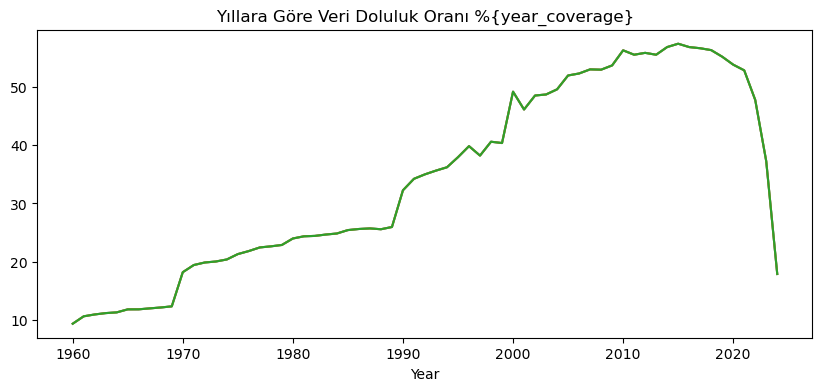

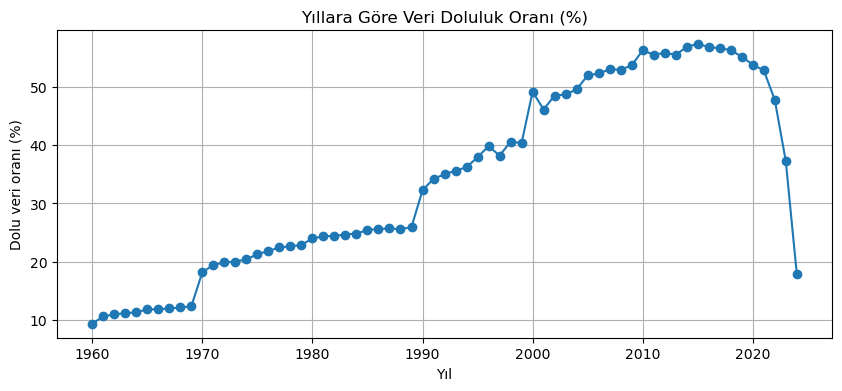

In [51]:
import matplotlib.pyplot as plt

year_coverage = (
    WDI_long.groupby("Year")["Value"]
    .apply(lambda x: x.notna().mean() * 100)
)

plt.figure(figsize=(10, 4))
plt.plot(year_coverage.index, year_coverage.values, marker='o')
plt.title("Yıllara Göre Veri Doluluk Oranı (%)")
plt.xlabel("Yıl")
plt.ylabel("Dolu veri oranı (%)")
plt.grid(True)
plt.show()




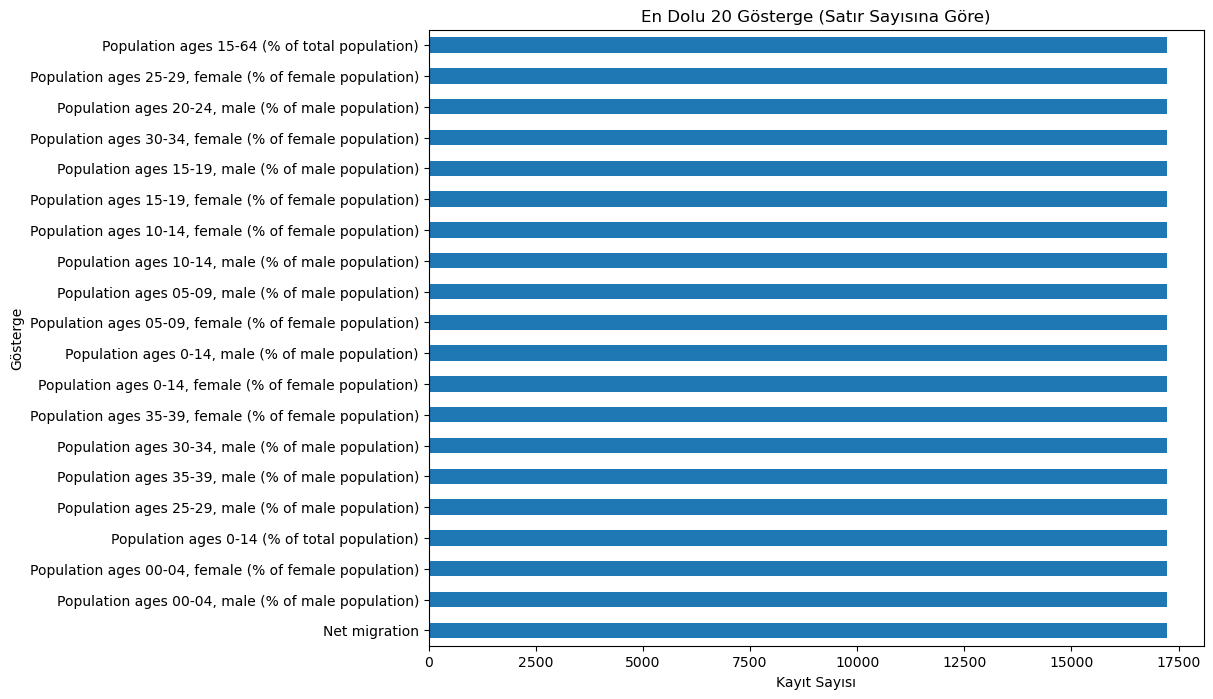

Indicator Name
Net migration                                             17225
Population ages 00-04, male (% of male population)        17225
Population ages 00-04, female (% of female population)    17225
Population ages 0-14 (% of total population)              17225
Population ages 25-29, male (% of male population)        17225
Population ages 35-39, male (% of male population)        17225
Population ages 30-34, male (% of male population)        17225
Population ages 35-39, female (% of female population)    17225
Population ages 0-14, female (% of female population)     17225
Population ages 0-14, male (% of male population)         17225
Population ages 05-09, female (% of female population)    17225
Population ages 05-09, male (% of male population)        17225
Population ages 10-14, male (% of male population)        17225
Population ages 10-14, female (% of female population)    17225
Population ages 15-19, female (% of female population)    17225
Population ages 15-19, ma

In [53]:
indicator_counts = (
    WDI_long.groupby("Indicator Name")["Value"]
    .count()
    .sort_values(ascending=False)
    .head(20)
)

indicator_counts.plot(kind="barh", figsize=(10,8))
plt.title("En Dolu 20 Gösterge (Satır Sayısına Göre)")
plt.xlabel("Kayıt Sayısı")
plt.ylabel("Gösterge")
plt.show()

indicator_counts


In [55]:
# 2000–2021 arası veriyi filtrele
WDI_filtered = WDI_long[(WDI_long["Year"] >= 2000) & (WDI_long["Year"] <= 2021)]


In [56]:
non_population = WDI_filtered[~WDI_filtered["Indicator Name"].str.contains("Population", case=False, na=False)]

indicator_counts_nonpop = (
    non_population.groupby("Indicator Name")["Value"]
    .count()
    .sort_values(ascending=False)
    .head(20)
)
indicator_counts_nonpop


Indicator Name
Survival to age 65, female (% of cohort)                         5830
Survival to age 65, male (% of cohort)                           5830
Adolescent fertility rate (births per 1,000 women ages 15-19)    5830
Sex ratio at birth (male births per female births)               5830
Birth rate, crude (per 1,000 people)                             5830
Net migration                                                    5830
Death rate, crude (per 1,000 people)                             5830
Life expectancy at birth, total (years)                          5830
Life expectancy at birth, male (years)                           5830
Life expectancy at birth, female (years)                         5830
Fertility rate, total (births per woman)                         5830
Mortality rate, adult, male (per 1,000 male adults)              5816
Mortality rate, adult, female (per 1,000 female adults)          5816
Capture fisheries production (metric tons)                       5808
Surfa

In [57]:
# Analizde kullanacağımız göstergeler:
indicators = [
    "Life expectancy at birth, total (years)",
    "Fertility rate, total (births per woman)",
    "Death rate, crude (per 1,000 people)",
    "Birth rate, crude (per 1,000 people)",
    "GDP per capita (current US$)",
    "Adolescent fertility rate (births per 1,000 women ages 15-19)"
]

# İlgili verileri filtrele
subset = WDI_filtered[WDI_filtered["Indicator Name"].isin(indicators)]

# Geniş formata çevir (ülke, yıl -> sütunlar = göstergeler)
pivot_df = subset.pivot_table(
    values="Value",
    index=["Country Name", "Year"],
    columns="Indicator Name"
).reset_index()

pivot_df.head()


Indicator Name,Country Name,Year,"Adolescent fertility rate (births per 1,000 women ages 15-19)","Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)","Fertility rate, total (births per woman)",GDP per capita (current US$),"Life expectancy at birth, total (years)"
0,Afghanistan,2000,154.310,51.491,12.608,7.566,174.930991,55.005
1,Afghanistan,2001,152.471,49.623,11.954,7.453,138.706822,55.511
2,Afghanistan,2002,150.161,47.488,11.187,7.320,178.954088,56.225
3,Afghanistan,2003,143.750,47.056,10.714,7.174,198.871116,57.171
4,Afghanistan,2004,136.930,46.492,10.375,7.018,221.763654,57.810


In [58]:
pivot_df = pivot_df.dropna(subset=["Life expectancy at birth, total (years)"])
pivot_df = pivot_df.dropna(thresh=5)  # çok eksik satırları at


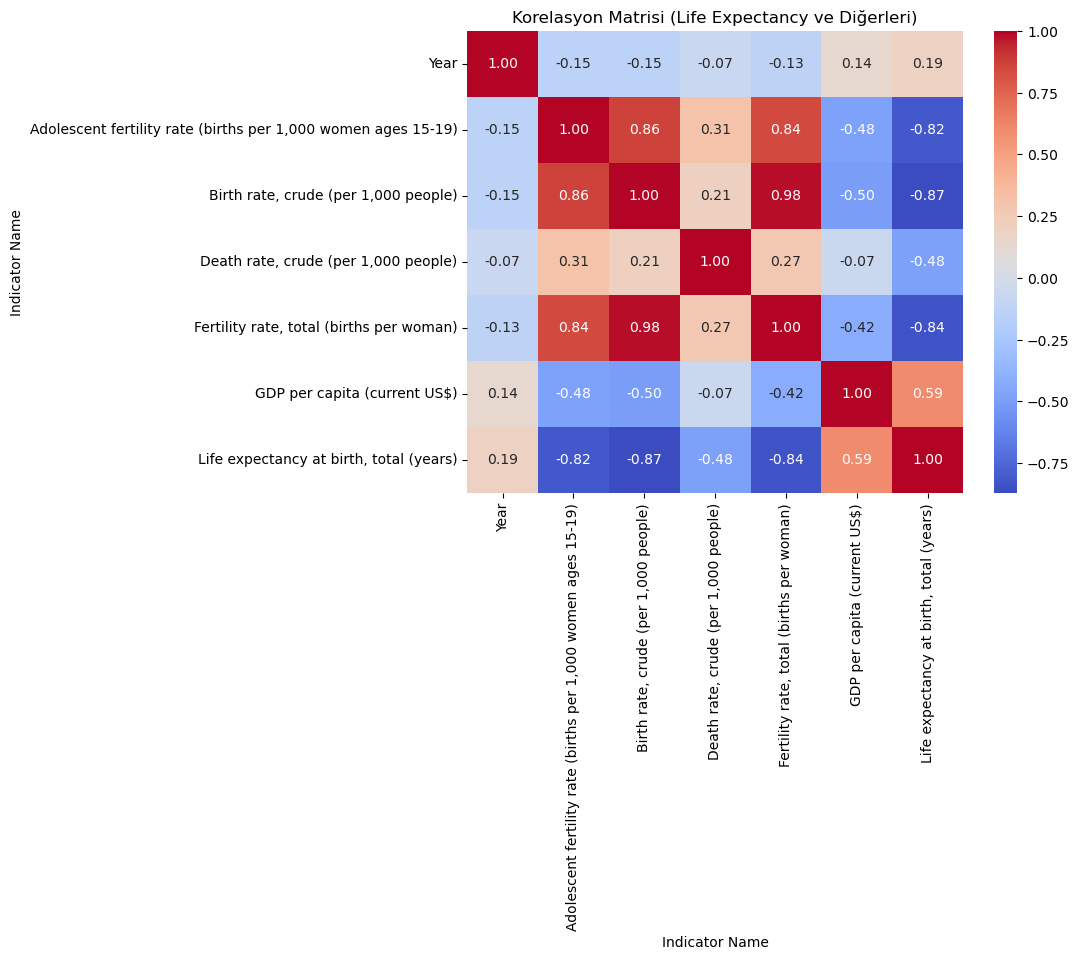

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = pivot_df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi (Life Expectancy ve Diğerleri)")
plt.show()

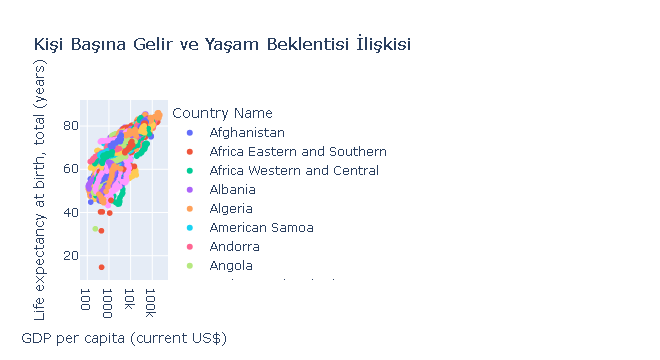

In [61]:
import plotly.express as px

px.scatter(
    pivot_df,
    x="GDP per capita (current US$)",
    y="Life expectancy at birth, total (years)",
    color="Country Name",
    title="Kişi Başına Gelir ve Yaşam Beklentisi İlişkisi",
    log_x=True
)


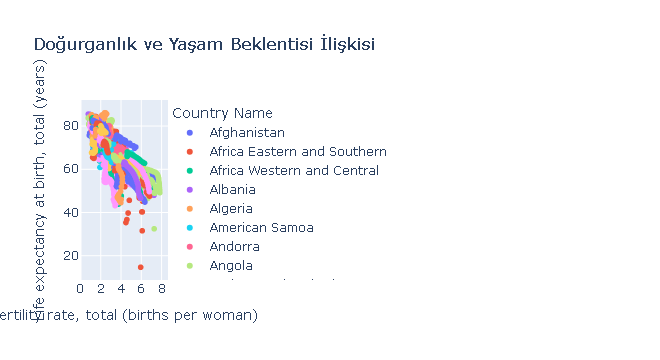

In [62]:
px.scatter(
    pivot_df,
    x="Fertility rate, total (births per woman)",
    y="Life expectancy at birth, total (years)",
    color="Country Name",
    title="Doğurganlık ve Yaşam Beklentisi İlişkisi"
)


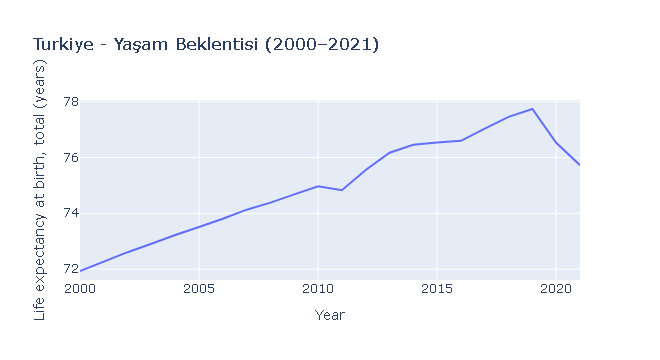

In [69]:
country = "Turkiye"
px.line(
    pivot_df[pivot_df["Country Name"]==country],
    x="Year",
    y="Life expectancy at birth, total (years)",
    title=f"{country} - Yaşam Beklentisi (2000–2021)"
)


In [66]:
country = "Turkey"
pivot_df[pivot_df["Country Name"] == country]


Indicator Name,Country Name,Year,"Adolescent fertility rate (births per 1,000 women ages 15-19)","Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)","Fertility rate, total (births per woman)",GDP per capita (current US$),"Life expectancy at birth, total (years)"


In [68]:
pivot_df["Country Name"].unique()[20:]


array(['Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Canada', 'Caribbean small states', 'Cayman Islands',
       'Central African Republic', 'Central Europe and the Baltics',
       'Chad', 'Channel Islands', 'Chile', 'China', 'Colombia', 'Comoros',
       'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cuba', 'Curacao', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic',
       'Early-demographic dividend', 'East Asia & Pacific',
       'East Asia & Pacific (IDA & IBRD countries)',
       'East Asia & Pacific (excluding high income)', 'Ecuador',
       'Egypt, Arab Rep.', 'El Salvador', 'Equatorial Guinea', 'Eritrea',
       'Estonia', 'Eswatini', 'Ethiopia', 'Euro area',
       'Europe & Cen

In [70]:
from sklearn.linear_model import LinearRegression
import numpy as np

model_df = pivot_df.dropna()
X = model_df[[
    "GDP per capita (current US$)",
    "Fertility rate, total (births per woman)",
    "Death rate, crude (per 1,000 people)"
]]
y = model_df["Life expectancy at birth, total (years)"]

# log(GDP) dönüşümü
X["GDP per capita (current US$)"] = np.log(X["GDP per capita (current US$)"])

model = LinearRegression()
model.fit(X, y)
print("R²:", model.score(X, y))
print("Katsayılar:", model.coef_)

 

R²: 0.8657812546320316
Katsayılar: [ 2.49586728 -2.6090954  -0.68931068]


C:\Users\musta\AppData\Local\Temp\ipykernel_31216\4156922340.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [71]:
print("Katsayılar:", model.coef_)
print("R²:", model.score(X, y))


Katsayılar: [ 2.49586728 -2.6090954  -0.68931068]
R²: 0.8657812546320316


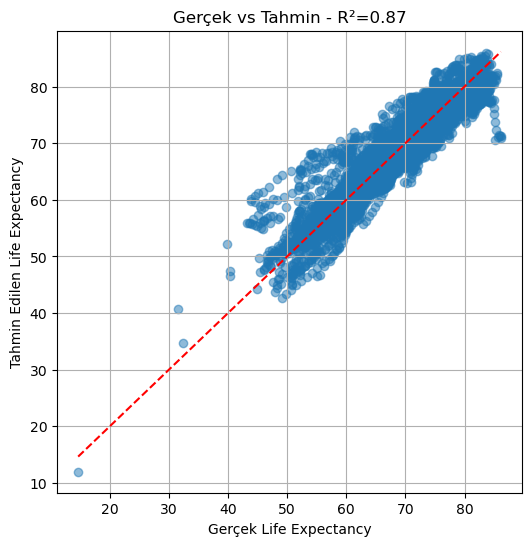

In [72]:
import matplotlib.pyplot as plt

y_pred = model.predict(X)

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Gerçek Life Expectancy")
plt.ylabel("Tahmin Edilen Life Expectancy")
plt.title(f"Gerçek vs Tahmin - R²={model.score(X, y):.2f}")
plt.grid(True)
plt.show()


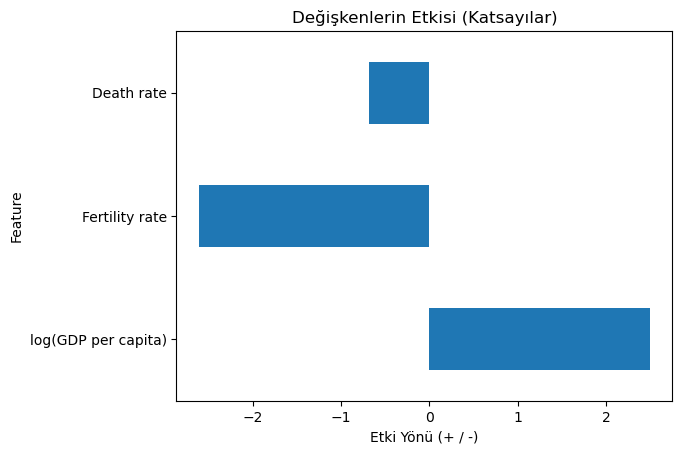

In [73]:
coef_df = pd.DataFrame({
    "Feature": ["log(GDP per capita)", "Fertility rate", "Death rate"],
    "Coefficient": model.coef_
})
coef_df.plot(kind="barh", x="Feature", legend=False, title="Değişkenlerin Etkisi (Katsayılar)")
plt.xlabel("Etki Yönü (+ / -)")
plt.show()


In [74]:
effect = model.coef_[0] * np.log(1.1)
print("GDP %10 artarsa yaşam süresi artışı:", round(effect,2), "yıl")


GDP %10 artarsa yaşam süresi artışı: 0.24 yıl


In [75]:
extra_indicators = [
    "Health expenditure (% of GDP)",
    "CO2 emissions (metric tons per capita)",
    "School enrollment, secondary (% gross)",
    "Unemployment, total (% of total labor force)",
    "People using safely managed drinking water services (% of population)"
]

# mevcut listeye ekle
indicators_extended = indicators + extra_indicators

subset_ext = WDI_filtered[WDI_filtered["Indicator Name"].isin(indicators_extended)]
pivot_df_ext = subset_ext.pivot_table(values="Value", index=["Country Name", "Year"],
                                      columns="Indicator Name").reset_index()

# log(GDP) dönüşümü yine yapılabilir
pivot_df_ext["log(GDP per capita)"] = np.log(pivot_df_ext["GDP per capita (current US$)"])

# eksik satırları temizle
pivot_df_ext = pivot_df_ext.dropna(subset=["Life expectancy at birth, total (years)"]).dropna(thresh=6)


In [76]:
X = pivot_df_ext[[col for col in pivot_df_ext.columns if col not in ["Country Name","Year","Life expectancy at birth, total (years)"]]]
y = pivot_df_ext["Life expectancy at birth, total (years)"]

model = LinearRegression().fit(X, y)
print("Yeni R²:", model.score(X, y))


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [77]:
target = "Life expectancy at birth, total (years)"
base_feats = [
    "GDP per capita (current US$)",
    "Fertility rate, total (births per woman)",
    "Death rate, crude (per 1,000 people)"
]

# Genişletmek istersen (1. seçenekten)
extra_feats = [
    "Health expenditure (% of GDP)",
    "CO2 emissions (metric tons per capita)",
    "School enrollment, secondary (% gross)",
    "Unemployment, total (% of total labor force)",
    "People using safely managed drinking water services (% of population)"
]

use_feats = base_feats  # istersen -> base_feats + extra_feats

In [78]:
pivot = WDI_filtered[WDI_filtered["Indicator Name"].isin([target] + use_feats)] \
    .pivot_table(values="Value", index=["Country Name","Year"], columns="Indicator Name") \
    .reset_index()

df = pivot.dropna(subset=[target])                # hedef NaN olmasın
df_drop = df.dropna(subset=use_feats)             # öz.nitelikler NaN olmasın

X = df_drop[use_feats].copy()
y = df_drop[target].copy()

# log GDP (pozitif olanlarda)
if "GDP per capita (current US$)" in X.columns:
    X["log_GDPpc"] = np.log(X["GDP per capita (current US$)"].clip(lower=1))
    X = X.drop(columns=["GDP per capita (current US$)"])

from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X, y)
print("R² (dropna):", model.score(X, y))


R² (dropna): 0.8657812546320316


In [79]:
# 2.1 Pivot
pivot = WDI_filtered[WDI_filtered["Indicator Name"].isin([target] + use_feats)] \
    .pivot_table(values="Value", index=["Country Name","Year"], columns="Indicator Name") \
    .reset_index()

# 2.2 Ülke bazlı lineer interpolasyon (yıl içinde)
def country_interpolate(g):
    return g.sort_values("Year").interpolate(limit_direction="both")

dfi = pivot.groupby("Country Name", group_keys=False).apply(country_interpolate)

# 2.3 Kalan boşlukları sütun medyanı ile doldur
dfi[ [target] + use_feats ] = dfi[ [target] + use_feats ].fillna(dfi.median(numeric_only=True))

# 2.4 Son filtre: hedef yine dolu olmalı
dfi = dfi.dropna(subset=[target])

X = dfi[use_feats].copy()
y = dfi[target].copy()

# log GDP
if "GDP per capita (current US$)" in X.columns:
    X["log_GDPpc"] = np.log(X["GDP per capita (current US$)"].clip(lower=1))
    X = X.drop(columns=["GDP per capita (current US$)"])

from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X, y)
print("R² (interp+median):", model.score(X, y))


C:\Users\musta\AppData\Local\Temp\ipykernel_31216\466408848.py:8: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.

C:\Users\musta\AppData\Local\Temp\ipykernel_31216\466408848.py:8: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.

C:\Users\musta\AppData\Local\Temp\ipykernel_31216\466408848.py:8: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.

C:\Users\musta\AppData\Local\Temp\ipykernel_31216\466408848.py:8: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.

C:\Users\musta\AppData\Local\Temp\ipykernel_3121

R² (interp+median): 0.8612039248755687


C:\Users\musta\AppData\Local\Temp\ipykernel_31216\466408848.py:8: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.

C:\Users\musta\AppData\Local\Temp\ipykernel_31216\466408848.py:8: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.

C:\Users\musta\AppData\Local\Temp\ipykernel_31216\466408848.py:8: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.

C:\Users\musta\AppData\Local\Temp\ipykernel_31216\466408848.py:8: FutureWarning:

DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.

C:\Users\musta\AppData\Local\Temp\ipykernel_3121

In [80]:
import numpy as np
import pandas as pd

target = "Life expectancy at birth, total (years)"
use_feats = [
    "GDP per capita (current US$)",
    "Fertility rate, total (births per woman)",
    "Death rate, crude (per 1,000 people)",
    # varsa eklediklerin burada
]

# 1) Pivot
pivot = (
    WDI_filtered[WDI_filtered["Indicator Name"].isin([target] + use_feats)]
    .pivot_table(values="Value", index=["Country Name", "Year"], columns="Indicator Name")
    .reset_index()
)

# 2) Sütun türlerini düzgünleştir: Year=int, metinler=str, göstergeler=numeric
pivot["Year"] = pd.to_numeric(pivot["Year"], errors="coerce").astype("Int64")
pivot["Country Name"] = pivot["Country Name"].astype("string")

value_cols = [c for c in pivot.columns if c not in ["Country Name", "Year"]]
# Sayısal dönüştürme: object->numeric (hatalılar NaN olur)
pivot[value_cols] = pivot[value_cols].apply(pd.to_numeric, errors="coerce")

# 3) Ülke içinde yıl bazında sıralayıp SADECE sayısal sütunlarda interpolate yap
def country_interpolate(g):
    g = g.sort_values("Year").copy()
    num_cols = g.select_dtypes(include=["number", "Float64", "Int64"]).columns
    # Year'ı hariç tut (interpolate etmeyeceğiz)
    num_cols = [c for c in num_cols if c != "Year"]
    g[num_cols] = g[num_cols].interpolate(method="linear", limit_direction="both")
    return g

dfi = pivot.groupby("Country Name", group_keys=False).apply(country_interpolate)

# 4) Kalan boşlukları sütun medyanı ile doldur (yalnızca sayısal sütunlar)
dfi[value_cols] = dfi[value_cols].fillna(dfi[value_cols].median(numeric_only=True))

# 5) Hedef boş olmasın
dfi = dfi.dropna(subset=[target])

# 6) Model girişi
X = dfi[use_feats].copy()
y = dfi[target].copy()

# 7) log(GDP) ekle, orijinali çıkar
if "GDP per capita (current US$)" in X.columns:
    X["log_GDPpc"] = np.log(X["GDP per capita (current US$)"].clip(lower=1))
    X = X.drop(columns=["GDP per capita (current US$)"])

from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X, y)
print("R² (interp+median, clean):", model.score(X, y))


R² (interp+median, clean): 0.8612039248755687


C:\Users\musta\AppData\Local\Temp\ipykernel_31216\1909790702.py:36: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [81]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.linear_model import LinearRegression

# Pivot (aynı)
pivot = WDI_filtered[WDI_filtered["Indicator Name"].isin([target] + use_feats)] \
    .pivot_table(values="Value", index=["Country Name","Year"], columns="Indicator Name") \
    .reset_index()

dfp = pivot.dropna(subset=[target]).copy()
groups = dfp["Country Name"].values   # ülkeye göre gruplama
X = dfp[use_feats].copy()
y = dfp[target].values

# GDP'ye özel log dönüşümü (imputasyondan SONRA uygulanacak)
def add_log_gdp(X_df):
    X_df = X_df.copy()
    if "GDP per capita (current US$)" in X_df.columns:
        X_df["log_GDPpc"] = np.log(np.clip(X_df["GDP per capita (current US$)"], 1, None))
        X_df = X_df.drop(columns=["GDP per capita (current US$)"])
    return X_df

log_gdp = FunctionTransformer(add_log_gdp, feature_names_out="one-to-one")

numeric_features = use_feats
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_gdp", log_gdp),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)],
    remainder="drop"
)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LinearRegression())
])

cv = GroupKFold(n_splits=5)  # ülke bazlı katlamalı doğrulama
scores = cross_val_score(pipe, X, y, cv=cv, groups=groups, scoring="r2")
print("CV R² (mean±std):", scores.mean().round(3), "±", scores.std().round(3))

pipe.fit(X, y)


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "D:\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Anaconda\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "D:\Anaconda\Lib\site-packages\sklearn\pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
  File "D:\Anaconda\Lib\site-packages\sklearn\pipeline.py", line 588, in _fit
    X, fitted_transformer = fit_transform_one_cached(
                            ~~~~~~~~~~~~~~~~~~